In [1]:
import pandas as pd
from statsmodels.tsa.api import VAR
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Date locale exportate din API DateModelare (agregat national 2016-2025) - vezi README.
source_df = pd.read_csv("venituri_total.csv")
indicatori_df = pd.read_csv("indicatori_total.csv")

In [3]:
from sklearn.preprocessing import RobustScaler


full_df = pd.merge(
  source_df,
  indicatori_df.rename(columns={'Data': 'data_indicatori'}),
  how='left',
  left_on='Data',
  right_on='data_indicatori'
).drop(columns=['data_indicatori'])

serie_df = full_df[['Data', 'Valoare', 'PIB']].rename(columns={'Data': 'Date', 'Valoare': 'Income'}).sort_values(by='Date').reset_index(drop=True)
scaler_income = RobustScaler()
scaler_pib = RobustScaler()
serie_df['Income'] = scaler_income.fit_transform(serie_df[['Income']])
serie_df['PIB'] = scaler_pib.fit_transform(serie_df[['PIB']])


In [4]:
train_size = int(len(serie_df) * 0.80)
train_df = serie_df.iloc[:train_size].reset_index(drop=True)
test_df = serie_df.iloc[train_size:].reset_index(drop=True)

In [5]:
cols=['Income', 'PIB']
model=VAR(train_df[cols])
res=model.fit(maxlags=10,ic='aic')
fc=res.forecast(train_df[cols].values[-res.k_ar:],len(test_df))
y_pred=fc[:,cols.index('Income')]

In [6]:
print(res.summary())
print(res.params)

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 29, Jun, 2026
Time:                     17:02:20
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -5.36947
Nobs:                     85.0000    HQIC:                  -6.02224
Log likelihood:           71.3932    FPE:                 0.00158666
AIC:                     -6.46148    Det(Omega_mle):      0.00105988
--------------------------------------------------------------------
Results for equation Income
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.097412         0.049340            1.974           0.048
L1.Income         0.153398         0.116337            1.319           0.187
L1.PIB           -0.079083         0.411867           -0.192           0.84

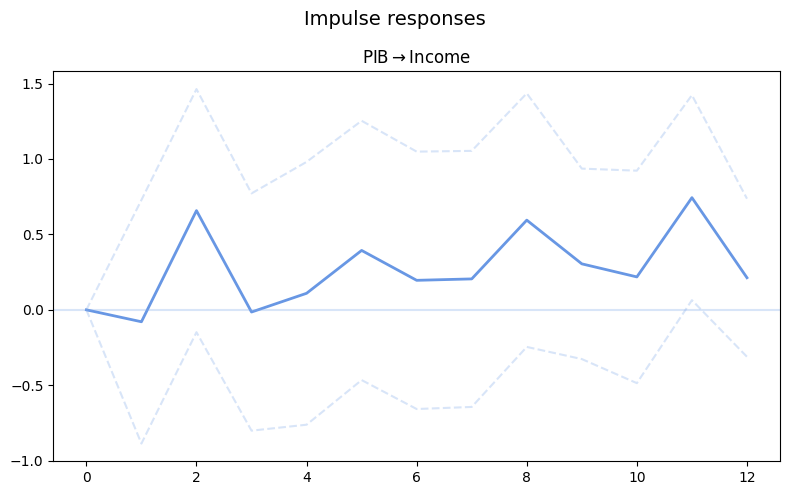

In [7]:
# generezi IRF-ul pe 12 perioade
irf = res.irf(12)

# obții figura
fig = irf.plot(orth=False, impulse="PIB", response="Income")

# modifici axele (fig are o listă de ax obiecte)
ax = fig.axes[0]

# titlu personalizat
#ax.set_title("PIB → Income", fontsize=14)

# culoarea liniei (linia 0 este IRF-ul, linia 1 și 2 sunt intervalele CI)
lines = ax.get_lines()
lines[0].set_color("#6897e4")     # IRF line → albastru deschis Seaborn
lines[0].set_linewidth(2)

# eventual poți modifica și benzile de încredere (CI)
for l in lines[1:]:
    l.set_color("#81a9e9")
    l.set_alpha(0.3)

# dimensiunea figurii
fig.set_size_inches(8, 5)

plt.tight_layout()
plt.show()